# Linear Algebra for Machine Learning

Linear algebra is the language of data. We use it to represent and manipulate everything from user profiles and images to the weights of a neural network.

This notebook builds geometric intuition for core concepts and connects them directly to modern ML applications.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image

np.set_printoptions(precision=4, suppress=True)

# 1. Vectors: The Atoms of Data

In ML, a vector is a list of numbers that represents a piece of data. Each number is a **feature**.

**Example: A User Vector**
Imagine we're building a recommendation system. A user could be represented by a vector:

`user_a = [age, movies_watched, avg_rating]`
`user_a = [34, 150, 4.5]`

This vector is a single point in a 3-dimensional 'user space'.

What is a vector?

A vector is:
<br/>•	A direction
<br/>•	A magnitude
<br/>•	A point in space

In ML:
<br/>•	A data point = vector
<br/>•	A weight set = vector

In [3]:
# A data point is a vector
user_a = np.array([34, 150, 4.5])

# Model weights are also vectors (or matrices)
weights = np.array([0.1, -0.5, 2.0])

print("User A:", user_a)
print("Model Weights:", weights)

User A: [ 34.  150.    4.5]
Model Weights: [ 0.1 -0.5  2. ]


# Visualize Vectors in 2D

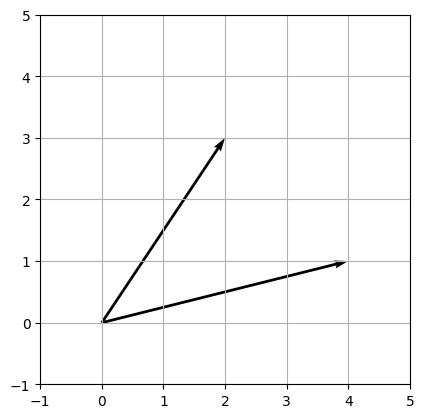

In [8]:
v = np.array([2, 3])
w = np.array([4, 1])

plt.figure()
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1)

plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# Vector Addition

Geometrically:
<br/>
You place one arrow at the tip of another.

In [9]:
v_plus_w = v + w
print("v + w =", v_plus_w)

v + w = [6 4]


# 2. The Dot Product: Measuring Similarity

The dot product tells us how 'aligned' two vectors are.
<br/><br/>
Formula:

`v.w = v_1.w_1 + v_2.w_2 + ... + v_n.w_n`

But geometrically:
`v · w = ||v|| ||w|| cos(θ)`

It measures:
<br/>•	Similarity
<br/>•	Alignment
<br/>•	Projection


Its most important use in modern ML is to measure **similarity**.

In [4]:
user_a = np.array([5, 4]) # Likes action and sci-fi
user_b = np.array([4, 5]) # Likes action and sci-fi (similar)
user_c = np.array([1, 2]) # Likes comedy and romance (dissimilar)

similarity_ab = np.dot(user_a, user_b)
similarity_ac = np.dot(user_a, user_c)

print(f"Similarity between User A and B: {similarity_ab}")
print(f"Similarity between User A and C: {similarity_ac}")

Similarity between User A and B: 40
Similarity between User A and C: 13


### Modern Application: Attention Mechanisms

The core of the Transformer architecture (used in models like GPT) is the **scaled dot-product attention**.

1. Every word in a sentence is represented by a vector (a 'Query' vector `Q`).
2. To decide which other words to pay attention to, this `Q` vector is 'dotted' with the 'Key' vectors (`K`) of all other words.
3. A large dot product score means high similarity, so the model pays more attention to that word when processing the current one.

**`Attention_Score = dot(Q, K)`**

# What Does Dot Product Mean?

1. Dot > 0 → vectors point roughly same direction
2. Dot = 0 → orthogonal (90°)
3. Dot < 0 → opposite direction

Let’s compute angle:

In [11]:
dot = np.dot(v, w)
print("Dot product:", dot)

cos_theta = dot / (np.linalg.norm(v) * np.linalg.norm(w))
theta = np.arccos(cos_theta)

print("Angle (radians):", theta)
print("Angle (degrees):", np.degrees(theta))

Dot product: 11
Angle (radians): 0.7378150601204648
Angle (degrees): 42.27368900609373


# ML Insight
`•	Linear regression = dot product`
<br/>`•	Neural network neuron = dot product + bias`
<br/>`•	Cosine similarity = normalized dot product`

# Norm (Vector Length)

Norm = magnitude of vector

L2 Norm (Euclidean length):

||v|| = $\sqrt{v_1^2 + v_2^2}$

L1 Norm:

||v||₁ = |v₁| + |v₂|

Why Norm Matters in AI?
-	Regularization (L2)
-	Distance calculation
- Feature scaling
- Loss magnitude


In [15]:
norm_v = np.linalg.norm(v)
print("Norm of v:", norm_v)

print("L2 norm:", np.linalg.norm(v))
print("L1 norm:", np.linalg.norm(v, ord=1))

Norm of v: 3.605551275463989
L2 norm: 3.605551275463989
L1 norm: 5.0


# Projection

Projection of w onto v:

`proj_v(w) = (v·w / v·v) v`

This is the foundation of least squares regression.

In [16]:
proj = (np.dot(v, w) / np.dot(v, v)) * v
print("Projection of w onto v:", proj)

Projection of w onto v: [1.6923 2.5385]


# 3. Matrix Multiplication: Transforming Data

A matrix is a collection of vectors. In ML, a matrix multiplication `Wx` means applying a **linear transformation** to the data vector `x`.

A matrix is:
- A transformation
- A way to rotate, scale, project vectors

This is the fundamental operation of a neural network layer.

In [13]:
# A transformation matrix (e.g., a neural network layer's weights)
W = np.array([
    [0.8, 0.2],
    [-0.3, 1.1]
])

# An input data vector
x = np.array([2, 3])

# The transformation
output = W @ x

print("Input vector:", x)
print("Transformed vector:", output)

Input vector: [2 3]
Transformed vector: [2.2 2.7]


### The Power of Batching

Why do we use GPUs? Because they are masters of matrix multiplication.

Instead of processing one data vector `x` at a time, we can stack them into a data **matrix** `X` (a 'batch') and process them all in one go.

`Output_Matrix = Data_Matrix @ Weight_Matrix`
`(num_samples, num_neurons) = (num_samples, num_features) @ (num_features, num_neurons)`

This is why linear algebra is the language of deep learning performance.

In [6]:
# A batch of 4 data samples, each with 2 features
X_batch = np.array([
    [1, 0],
    [0, 1],
    [1, 1],
    [-1, 2]
])

# A weight matrix for a layer with 3 neurons
W_layer = np.random.rand(2, 3)

# Process the entire batch at once
batch_output = X_batch @ W_layer

print("Input Batch Shape:", X_batch.shape)
print("Weight Matrix Shape:", W_layer.shape)
print("Output Batch Shape:", batch_output.shape)
print("Output Batch:\n", batch_output)

Input Batch Shape: (4, 2)
Weight Matrix Shape: (2, 3)
Output Batch Shape: (4, 3)
Output Batch:
 [[ 0.7282  0.392   0.0506]
 [ 0.0214  0.6481  0.4485]
 [ 0.7496  1.0401  0.4991]
 [-0.6855  0.9041  0.8463]]


# Geometry of Matrix Multiplication

A @ x = [4 7]


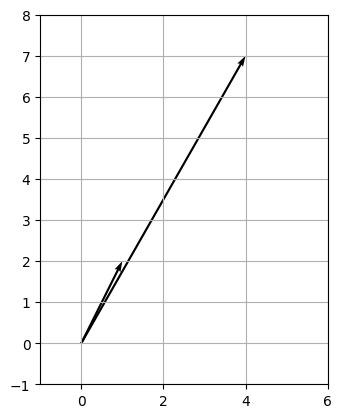

In [14]:
A = np.array([
    [2, 1],
    [1, 3]
])

x = np.array([1, 2])

result = A @ x
print("A @ x =", result)

plt.figure()

# original vector
plt.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1)

# transformed vector
plt.quiver(0, 0, result[0], result[1], angles='xy', scale_units='xy', scale=1)

plt.xlim(-1, 6)
plt.ylim(-1, 8)
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# 4. Singular Value Decomposition (SVD): Compressing Information

SVD is a powerful factorization that breaks any matrix `A` into three other matrices:

`A = U * S * Vᵀ`

- `U` and `V` are orthogonal matrices (representing rotations).
- `S` is a diagonal matrix of **singular values**.

The singular values in `S` tell us the 'importance' of each dimension. By throwing away the least important ones, we can create a **low-rank approximation** of the original matrix.


A = U Σ Vᵀ

- U → output directions
- Σ → scaling
- V → input directions


### Practical Use Case: Image Compression

An image is just a matrix of pixel values. We can use SVD to compress it.

Where SVD appears in ML

- PCA : Directions of max variance = right singular vectors V
- Recommender Systems : Decomposes user-item matrix to find latent factors
- NLP / LSA : Finds latent topics in a term-document matrix
- Image compression : Keep top-k singular values, discard the rest
- Pseudoinverse : A⁺ = V · S⁻¹ · Uᵀ for solving least squares

In [19]:
# Simulated dataset: 5 samples, 4 features
X = np.array([
    [2.5, 2.4, 3.1, 1.2],
    [0.5, 0.7, 1.1, 0.9],
    [2.2, 2.9, 3.0, 1.5],
    [1.9, 2.2, 2.8, 1.1],
    [3.1, 3.0, 4.2, 2.0],
])

# Step 1: Center the data (zero mean per feature)
X_centered = X - X.mean(axis=0)


# Step 2: Apply SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
# U  → (5×4) left singular vectors  (sample space)
# S  → (4,)  singular values         (importance of each component)
# Vt → (4×4) right singular vectors  (feature space)

# Step 3: Project down to 2D (keep top 2 components)
k = 2
X_reduced = X_centered @ Vt[:k].T   # shape: (5, 2)

# Step 4: How much variance is explained?
variance_explained = (S**2) / (S**2).sum()

print("Singular values:        ", S.round(3))
print("Variance explained:     ", variance_explained.round(3))
print("Reduced data (2D):\n",     X_reduced.round(3))

print("Singular values:", S)

Singular values:         [3.513 0.549 0.442 0.173]
Variance explained:      [0.959 0.023 0.015 0.002]
Reduced data (2D):
 [[-0.467 -0.009]
 [ 2.816 -0.157]
 [-0.558  0.401]
 [ 0.173  0.093]
 [-1.963 -0.328]]
Singular values: [3.513  0.5492 0.4419 0.1726]


# 5. PCA from Scratch

1. Center data
2. Compute covariance
3. Find eigenvectors
4. Project onto principal direction

In [20]:
np.random.seed(0)

X = np.random.randn(200, 2)
X[:, 1] = X[:, 0] * 0.8 + np.random.randn(200) * 0.2

X_centered = X - np.mean(X, axis=0)
cov = np.cov(X_centered.T)

eigvals, eigvecs = np.linalg.eig(cov)

principal_vector = eigvecs[:, np.argmax(eigvals)]

print("Principal direction:", principal_vector)

Principal direction: [0.7696 0.6386]


# Linear Algebra → Machine Learning

Linear Regression:
y = wᵀx

Neural Network Layer:
y = Wx + b

Regularization:
L2 = ||w||²
L1 = ||w||

Everything reduces to:
- Dot products
- Matrix multiplication
- Vector norms